# Figure 3 — Foundation validation: masked-band reconstruction (held-out tile)

Validation of the frozen v10 foundation on a **held-out** ECDFS tile (in the model's
validation split, unseen in training). For each of the ten bands in turn we withhold that band
and reconstruct it from the other nine (the pre-training objective), then compare truth vs
prediction. **Rows:** truth / model prediction. Each column is annotated with the bright-pixel
correlation r. The scatter pools the brightest pixels across all bands (pooled r).

Pure inference on `models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt`. Saves
`paper/figures/fig3_reconstruction.png`.

In [1]:
import sys, numpy as np, torch
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

def find_repo_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data').is_dir() and (c / 'paper').is_dir():
            return c
    raise RuntimeError('repo root not found')

REPO = find_repo_root()
sys.path.insert(0, str(REPO / 'models'))
FIGDIR = REPO / 'paper' / 'figures'; FIGDIR.mkdir(exist_ok=True)
from load_foundation import load_foundation
from jaisp_dataset_v10 import JAISPDatasetV10

CKPT = REPO / 'models' / 'checkpoints' / 'jaisp_v10_warmstart' / 'checkpoint_best.pt'
dev = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

ckpt = torch.load(str(CKPT), map_location='cpu', weights_only=False)
VAL_IDX = set(ckpt['val_indices'])
HELDOUT_IDX = 519   # a held-out (validation-split) ECDFS tile with Euclid coverage

model = load_foundation(str(CKPT), device=dev, freeze=True)
ds = JAISPDatasetV10(rubin_dir=str(REPO/'data'/'rubin_tiles_all'),
                     euclid_dir=str(REPO/'data'/'euclid_tiles_all'),
                     load_euclid=True, augment=False)
assert HELDOUT_IDX in VAL_IDX, 'chosen tile is NOT in the validation split!'
TILE = ds.tiles[HELDOUT_IDX]['tile_id']
sample = ds[HELDOUT_IDX]
pool = {}; pool.update(sample['rubin']); pool.update(sample.get('euclid', {}))
print('held-out tile:', TILE, '| in val split:', HELDOUT_IDX in VAL_IDX)
print('bands:', list(pool))

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt
JAISPDatasetV10: scanning 790 tiles...


  790 tiles passed quality cuts
  790 tiles have Euclid coverage


held-out tile: tile_x01792_y01280_tract5063_patch_4 | in val split: True
bands: ['rubin_u', 'rubin_g', 'rubin_r', 'rubin_i', 'rubin_z', 'rubin_y', 'euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H']


In [2]:
ORDER = ['rubin_u','rubin_g','rubin_r','rubin_i','rubin_z','rubin_y',
         'euclid_VIS','euclid_Y','euclid_J','euclid_H']
ORDER = [b for b in ORDER if b in pool]
PSCALE = {b: (0.2 if b.startswith('rubin') else 0.1) for b in ORDER}
FOV = 40.0  # arcsec central crop for display

def cc(a, ps):
    h = int(round(FOV/ps/2)); c0, c1 = a.shape[0]//2, a.shape[1]//2
    return a[c0-h:c0+h, c1-h:c1+h]

res = {}; scat_t = []; scat_p = []
for b in ORDER:
    ctx = [x for x in pool if x != b]
    ci = {x: pool[x]['image'].unsqueeze(0).to(dev) for x in ctx}
    cr = {x: pool[x]['rms'].unsqueeze(0).to(dev) for x in ctx}
    ti = pool[b]['image'].unsqueeze(0).to(dev); tr = pool[b]['rms'].unsqueeze(0).to(dev)
    with torch.no_grad():
        out = model(ci, cr, b, ti, tr)
    truth = out['target_norm'][0,0].cpu().numpy()
    pred  = out['pred'][0,0].cpu().numpy()
    info  = out['info_weights'][0,0].cpu().numpy()
    m = info >= np.nanpercentile(info, 90)
    r = float(np.corrcoef(truth[m], pred[m])[0,1])
    res[b] = dict(truth=cc(truth, PSCALE[b]), pred=cc(pred, PSCALE[b]), r=r)
    tb, pb = truth[m], pred[m]
    k = min(len(tb), 400); sel = np.linspace(0, len(tb)-1, k).astype(int)
    scat_t.append(tb[sel]); scat_p.append(pb[sel])
    print(f'{b:11s} r={r:.3f}')

scat_t = np.concatenate(scat_t); scat_p = np.concatenate(scat_p)
pooled_r = float(np.corrcoef(scat_t, scat_p)[0,1])
print('pooled r =', round(pooled_r, 3))

rubin_u     r=0.285


rubin_g     r=0.988


rubin_r     r=0.992


rubin_i     r=0.973


rubin_z     r=0.962


rubin_y     r=0.853


euclid_VIS  r=0.822


euclid_Y    r=0.892


euclid_J    r=0.922


euclid_H    r=0.932
pooled r = 0.986


saved /home/shemmati/Work/Projects/JAISP/paper/figures/fig3_reconstruction.png


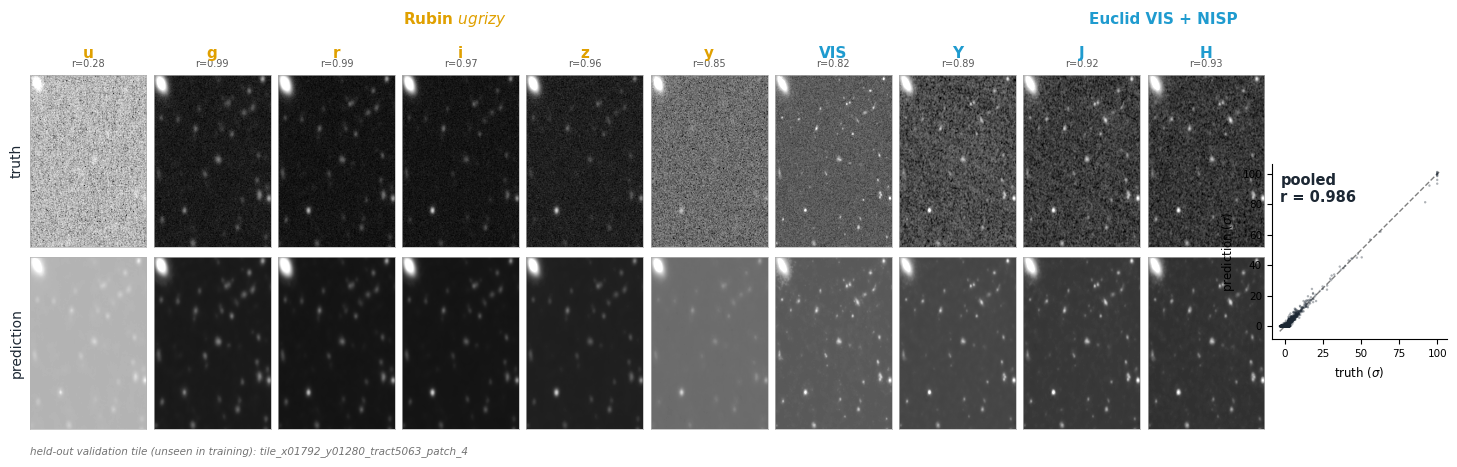

In [3]:
C_RUBIN = '#e0a000'; C_EUCLID = '#1f9bcf'; INK = '#1c2733'
LAB = {'rubin_u':'u','rubin_g':'g','rubin_r':'r','rubin_i':'i','rubin_z':'z','rubin_y':'y',
       'euclid_VIS':'VIS','euclid_Y':'Y','euclid_J':'J','euclid_H':'H'}
nb_ = len(ORDER)

fig = plt.figure(figsize=(15.0, 4.6))
gs = GridSpec(2, nb_ + 1, figure=fig, height_ratios=[1, 1],
              width_ratios=[1]*nb_ + [1.5], wspace=0.06, hspace=0.06,
              left=0.05, right=0.995, top=0.84, bottom=0.07)

rowlab = ['truth', 'prediction']
for j, b in enumerate(ORDER):
    d = res[b]
    nrm = ImageNormalize(d['truth'], interval=PercentileInterval(99.3), stretch=AsinhStretch(0.1))
    col = C_RUBIN if b.startswith('rubin') else C_EUCLID
    for i, key in enumerate(['truth', 'pred']):
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(d[key], origin='lower', cmap='gray', norm=nrm, aspect='auto')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_edgecolor('0.7'); s.set_linewidth(0.5)
        if i == 0:
            ax.set_title(LAB[b], fontsize=11, color=col, weight='bold', pad=12)
            ax.text(0.5, 1.03, f"r={d['r']:.2f}", transform=ax.transAxes, ha='center',
                    va='bottom', fontsize=7, color='0.35')
        if j == 0:
            ax.set_ylabel(rowlab[i], fontsize=10, color=INK)

# instrument group labels across the top
fig.text(0.05 + (3.0/nb_)*0.945, 0.95, 'Rubin $ugrizy$', ha='center', fontsize=11,
         color=C_RUBIN, weight='bold')
fig.text(0.05 + (8.0/nb_)*0.945, 0.95, 'Euclid VIS + NISP', ha='center', fontsize=11,
         color=C_EUCLID, weight='bold')

# pooled scatter (spans both rows, last column)
axs = fig.add_subplot(gs[:, nb_])
lim = [min(scat_t.min(), scat_p.min()), max(scat_t.max(), scat_p.max())]
axs.plot(lim, lim, '--', color='0.5', lw=1, zorder=1)
axs.scatter(scat_t, scat_p, s=3, c=INK, alpha=0.35, edgecolors='none', zorder=2)
axs.set_xlabel('truth ($\sigma$)', fontsize=8.5)
axs.set_ylabel('prediction ($\sigma$)', fontsize=8.5)
axs.text(0.05, 0.95, 'pooled\nr = %.3f' % pooled_r, transform=axs.transAxes, va='top',
         ha='left', fontsize=10.5, weight='bold', color=INK)
axs.tick_params(labelsize=7.5); axs.set_aspect('equal', 'box')
for s in ('top','right'): axs.spines[s].set_visible(False)

fig.text(0.05, 0.015, 'held-out validation tile (unseen in training): %s' % TILE,
         fontsize=7.5, color='0.45', style='italic')

out = FIGDIR / 'fig3_reconstruction.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('saved', out)
plt.show()